In [2]:
import pandas as pd

In [3]:
order_reviews_dataset = pd.read_csv('../data/order_reviews_dataset.csv')
print(order_reviews_dataset.shape)
order_reviews_dataset.head(3)

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [4]:
print(len(order_reviews_dataset[order_reviews_dataset['review_score']== 1]))
order_reviews_dataset[order_reviews_dataset['review_score']== 1].isnull().sum()

11424


review_id                     0
order_id                      0
review_score                  0
review_comment_title       9551
review_comment_message     2679
review_creation_date          0
review_answer_timestamp       0
dtype: int64

In [5]:
order_reviews_dataset['review_comment_message'][order_reviews_dataset['review_score'].isin([1,2])].value_counts()

review_comment_message
Não recebi o produto                                                                                                                                                                                         33
Não recebi o produto                                                                                                                                                                                         13
Não recebi                                                                                                                                                                                                   12
Ainda não recebi                                                                                                                                                                                             11
Ainda não recebi o produto                                                                                                                       

## Análisis de N-gramas — Definición de la Taxonomía de Categorías

Antes de clasificar con el LLM, se realizó un **análisis exploratorio de n-gramas** sobre el corpus de quejas (reseñas 1-2 estrellas con texto).

El objetivo era identificar inductivamente los grandes temas de insatisfacción desde los propios textos, sin imponer categorías a priori. Los patrones léxicos más frecuentes luego guiaron la definición de la taxonomía usada en la clasificación Zero-Shot.

**Proceso:**
1. Filtrar reseñas 1-2 estrellas con texto válido
2. Normalizar texto (minúsculas, eliminar puntuación y números)
3. Extraer top unigrams, bigrams y trigrams (removiendo stopwords en portugués)
4. Interpretar los clusters semánticos emergentes → definir categorías

In [6]:
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Filtro: reseñas 1-2 estrellas con texto ──────────────────────────────────
malas_exp = order_reviews_dataset[
    order_reviews_dataset['review_score'].isin([1, 2]) &
    order_reviews_dataset['review_comment_message'].notna()
].copy().reset_index(drop=True)

print(f"Corpus de quejas: {len(malas_exp)} comentarios")

# ── Stopwords en portugués ────────────────────────────────────────────────────
STOPWORDS_PT = {
    'a', 'o', 'e', 'de', 'do', 'da', 'dos', 'das', 'um', 'uma', 'em', 'no',
    'na', 'nos', 'nas', 'com', 'por', 'para', 'que', 'se', 'me', 'te', 'lhe',
    'ao', 'aos', 'pelo', 'pela', 'pelos', 'pelas', 'meu', 'minha', 'seu',
    'sua', 'este', 'esta', 'esse', 'essa', 'isso', 'isto', 'ele', 'ela',
    'eles', 'elas', 'eu', 'tu', 'nós', 'vós', 'mas', 'ou', 'quando', 'como',
    'muito', 'mais', 'bem', 'já', 'ainda', 'foi', 'ser', 'estar', 'tem',
    'ter', 'não', 'sim', 'até', 'desde', 'entre', 'sobre', 'pois', 'então',
    'porque', 'assim', 'também', 'só', 'ja', 'nao', 'que', 'r', 'q',
}

# ── Limpieza de texto ─────────────────────────────────────────────────────────
def clean_pt(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # quitar puntuación
    text = re.sub(r'\d+', '', text)          # quitar números
    text = re.sub(r'\s+', ' ', text).strip()
    # quitar stopwords
    tokens = [t for t in text.split() if t not in STOPWORDS_PT and len(t) > 2]
    return ' '.join(tokens)

malas_exp['texto_limpio'] = malas_exp['review_comment_message'].apply(clean_pt)

print(f"\nEjemplo de texto original vs. limpio:")
idx = malas_exp['texto_limpio'].str.len().sort_values(ascending=False).index[2]
print(f"  Original : {malas_exp.loc[idx, 'review_comment_message'][:120]}")
print(f"  Limpio   : {malas_exp.loc[idx, 'texto_limpio'][:120]}")

Corpus de quejas: 10890 comentarios

Ejemplo de texto original vs. limpio:
  Original : Comprei duas tesouras fio navalha sendo uma desfiadera ,chegou tudo certo mais abri a maecadoria oque estava dentro era 
  Limpio   : comprei duas tesouras fio navalha sendo desfiadera chegou tudo certo abri maecadoria oque estava dentro era outro produt


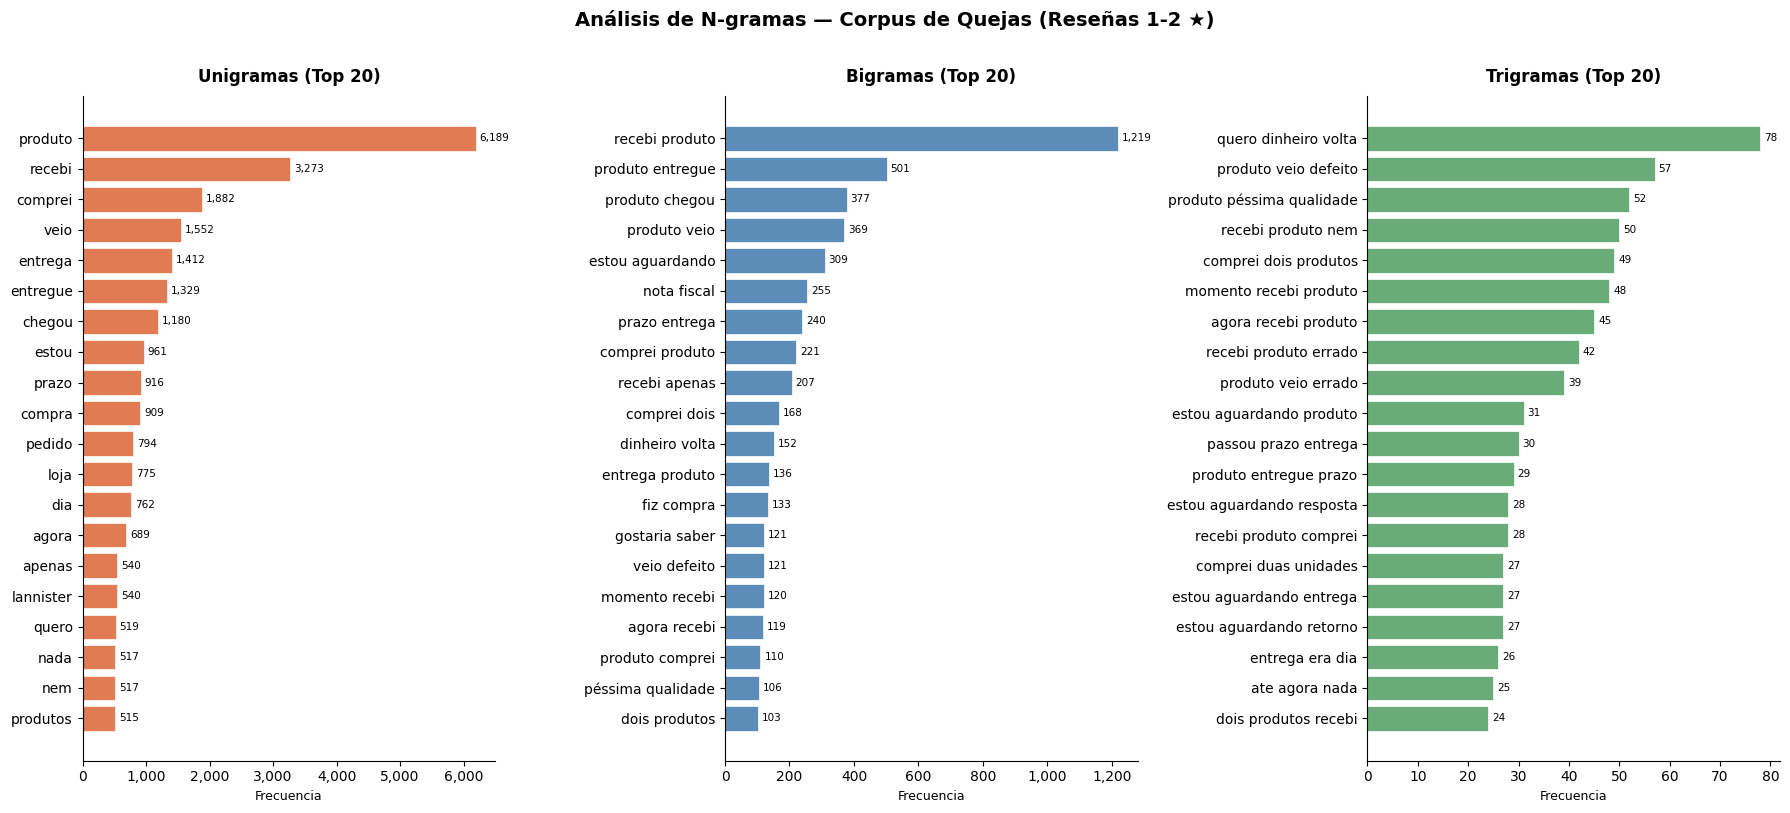

Gráfico guardado en outputs/p2_ngrams.png


In [7]:
def top_ngrams(corpus, n, top_k=25):
    """Extrae los top_k n-gramas más frecuentes del corpus."""
    vec = CountVectorizer(ngram_range=(n, n), min_df=3, max_features=5000)
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    counts = sorted(zip(vocab, freqs), key=lambda x: -x[1])
    return counts[:top_k]


def plot_ngrams(counts, title, ax, color):
    labels = [x[0] for x in counts]
    values = [x[1] for x in counts]
    bars = ax.barh(labels[::-1], values[::-1], color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Frecuencia', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, values[::-1]):
        ax.text(val + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{int(val):,}', va='center', fontsize=7.5)


corpus = malas_exp['texto_limpio'].tolist()

uni  = top_ngrams(corpus, n=1, top_k=20)
bi   = top_ngrams(corpus, n=2, top_k=20)
tri  = top_ngrams(corpus, n=3, top_k=20)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Análisis de N-gramas — Corpus de Quejas (Reseñas 1-2 ★)', fontsize=14, fontweight='bold', y=1.01)

plot_ngrams(uni, 'Unigramas (Top 20)', axes[0], '#e07b54')
plot_ngrams(bi,  'Bigramas (Top 20)',  axes[1], '#5b8db8')
plot_ngrams(tri, 'Trigramas (Top 20)', axes[2], '#6aab7a')

plt.tight_layout()
plt.savefig('../outputs/p2_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en outputs/p2_ngrams.png")

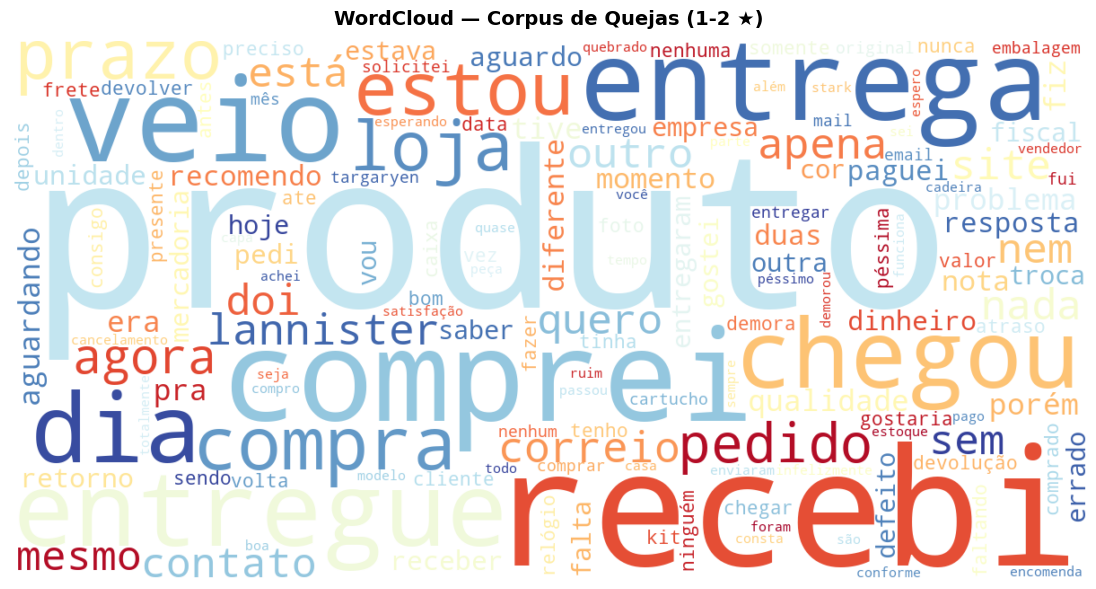

WordCloud guardado en outputs/p2_wordcloud.png


In [8]:
# WordCloud del corpus completo de quejas
try:
    from wordcloud import WordCloud

    all_text = ' '.join(malas_exp['texto_limpio'].tolist())

    wc = WordCloud(
        width=1200, height=600,
        background_color='white',
        colormap='RdYlBu_r',
        max_words=150,
        collocations=False,
        prefer_horizontal=0.85,
    ).generate(all_text)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('WordCloud — Corpus de Quejas (1-2 ★)', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('../outputs/p2_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("WordCloud guardado en outputs/p2_wordcloud.png")
except ImportError:
    print("wordcloud no instalado. Ejecutar: uv add wordcloud")

In [9]:
# ── Tabla resumen: qué n-gramas anclan cada categoría ────────────────────────
mapping = {
    'Logistica_Retrasos': [
        'entrega', 'recebi', 'prazo', 'chegou', 'correio', 'transportadora',
        'nao recebi', 'nao chegou', 'ainda nao', 'nao recebi produto',
        'ainda nao recebi', 'prazo entrega', 'entrega atrasada',
    ],
    'Calidad_Producto': [
        'qualidade', 'defeito', 'quebrado', 'danificado', 'pessimo',
        'qualidade pessima', 'produto defeituoso', 'chegou quebrado',
        'produto danificado', 'qualidade produto',
    ],
    'Producto_Incorrecto_Faltante': [
        'errado', 'diferente', 'faltou', 'incompleto', 'outro produto',
        'produto errado', 'veio diferente', 'nao era', 'produto diferente',
        'veio errado', 'diferente foto',
    ],
    'Reembolso_Atencion_Cliente': [
        'reembolso', 'devolucao', 'atendimento', 'resposta', 'contato',
        'quero reembolso', 'solicito devolucao', 'sem resposta',
        'atendimento pessimo', 'nao respondeu',
    ],
    'Problema_Fiscal_Burocracia': [
        'nota fiscal', 'nfe', 'imposto', 'fiscal', 'documento',
        'nota fiscal nao', 'problema nota', 'sem nota fiscal',
    ],
}

print("=" * 70)
print("MAPEO N-GRAMAS → TAXONOMÍA DE CATEGORÍAS")
print("=" * 70)
print(f"\n{'Categoría':<32}  Señales léxicas identificadas")
print("-" * 70)
for cat, signals in mapping.items():
    uni_signals  = [s for s in signals if len(s.split()) == 1]
    bi_signals   = [s for s in signals if len(s.split()) == 2]
    tri_signals  = [s for s in signals if len(s.split()) >= 3]
    print(f"\n{cat}")
    if uni_signals:  print(f"  Unigramas : {', '.join(uni_signals)}")
    if bi_signals:   print(f"  Bigramas  : {', '.join(bi_signals)}")
    if tri_signals:  print(f"  Trigramas : {', '.join(tri_signals)}")

print("\n" + "=" * 70)
print("CONCLUSIÓN: los n-gramas revelaron 5 clusters semánticos claros.")
print("La categoría 'Otro' captura el residuo (~6%) no atribuible a ninguno.")
print("=" * 70)

MAPEO N-GRAMAS → TAXONOMÍA DE CATEGORÍAS

Categoría                         Señales léxicas identificadas
----------------------------------------------------------------------

Logistica_Retrasos
  Unigramas : entrega, recebi, prazo, chegou, correio, transportadora
  Bigramas  : nao recebi, nao chegou, ainda nao, prazo entrega, entrega atrasada
  Trigramas : nao recebi produto, ainda nao recebi

Calidad_Producto
  Unigramas : qualidade, defeito, quebrado, danificado, pessimo
  Bigramas  : qualidade pessima, produto defeituoso, chegou quebrado, produto danificado, qualidade produto

Producto_Incorrecto_Faltante
  Unigramas : errado, diferente, faltou, incompleto
  Bigramas  : outro produto, produto errado, veio diferente, nao era, produto diferente, veio errado, diferente foto

Reembolso_Atencion_Cliente
  Unigramas : reembolso, devolucao, atendimento, resposta, contato
  Bigramas  : quero reembolso, solicito devolucao, sem resposta, atendimento pessimo, nao respondeu

Problema_Fiscal_

### Interpretación del análisis de n-gramas

Los n-gramas más frecuentes del corpus revelaron **5 clusters semánticos** bien diferenciados:

| Categoría definida | Señal léxica dominante | Ejemplo de trigrama |
|---|---|---|
| **Logistica_Retrasos** | `recebi`, `entrega`, `prazo`, `correio` | *"ainda nao recebi"*, *"prazo entrega"* |
| **Calidad_Producto** | `qualidade`, `defeito`, `quebrado`, `pessimo` | *"chegou quebrado"*, *"produto defeituoso"* |
| **Producto_Incorrecto_Faltante** | `errado`, `diferente`, `faltou` | *"veio diferente foto"*, *"produto errado"* |
| **Reembolso_Atencion_Cliente** | `reembolso`, `atendimento`, `sem resposta` | *"quero reembolso"*, *"atendimento pessimo"* |
| **Problema_Fiscal_Burocracia** | `nota fiscal`, `nfe`, `fiscal` | *"sem nota fiscal"* |

**Decisión:** Se añadió `Otro` como categoría residual para capturar el ~6% de quejas que no encajan en ningún cluster (e.g., comentarios muy cortos como *"Péssimo"*, quejas mixtas, etc.).

Estos 6 labels fueron los usados en el prompt Zero-Shot enviado a `granite4:3b` para la clasificación masiva.